## Import Statements

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the excel file

In [89]:
df = pd.read_excel("P652-Dataset.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [90]:
df.shape

(1440, 3)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [92]:
df.describe(include='all')

,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Very disappointed with the overall performance...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


In [93]:
#Missing Values
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [94]:
#Duplicate Records 
df.duplicated().sum()

np.int64(0)

### Creating Sentiment labels

In [95]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
df["Sentiment"] = df["rating"].apply(sentiment_label)

### Text preprocessing

In [96]:
import re
import string
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

In [97]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PORUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PORUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PORUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [98]:
df.columns.tolist()

['title', 'rating', 'body', 'Sentiment']

# EDA(Exploratory Data Analysis)

### Rating Distribution

C:\Users\PORUS\AppData\Local\Temp\ipykernel_16920\2752114867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating',data=df,palette='viridis')


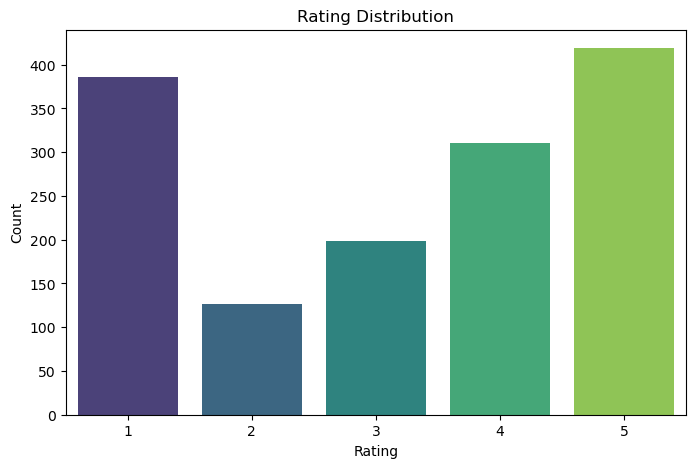

In [99]:
#Rating Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='rating',data=df,palette='viridis')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Sentiment Distribution

C:\Users\PORUS\AppData\Local\Temp\ipykernel_16920\3973189335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment',data=df,palette='Set2')


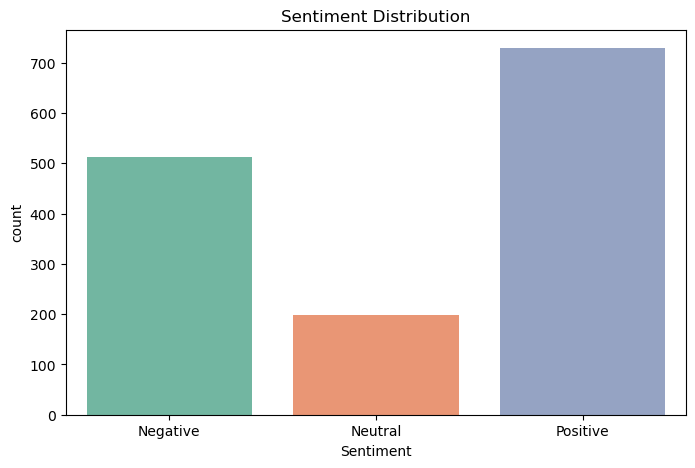

In [100]:
#To Visualize the number of Positive, Neutral, and Negative reviews
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment',data=df,palette='Set2')
plt.title("Sentiment Distribution")
plt.show()

### Sentiment Percentage Pie Chart

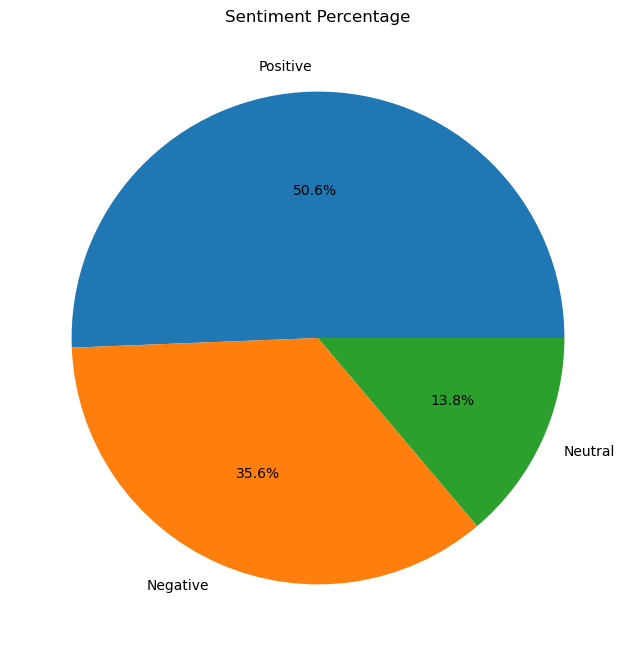

In [101]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(sentiment_counts,labels=sentiment_counts.index,autopct="%1.1f%%")
plt.title("Sentiment Percentage")
plt.show()

### Review length

In [102]:
# Combine Title + Review
df["review"] = df["title"] + " " + df["body"]

### create feature

In [103]:
df["review_length"] = df["review"].apply(len)

### Histogram

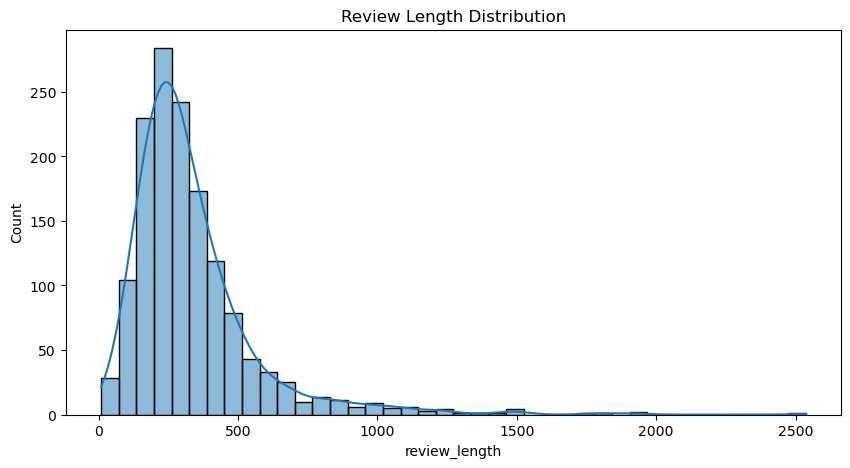

In [104]:
plt.figure(figsize=(10,5))
sns.histplot(df["review_length"],bins=40,kde=True)
plt.title("Review Length Distribution")
plt.show()

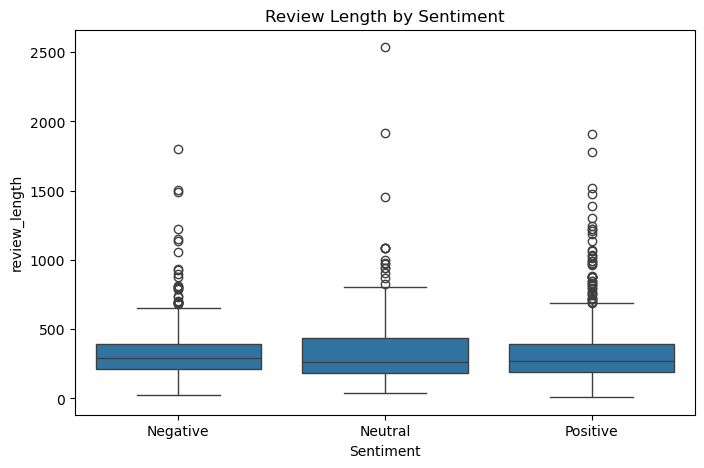

In [105]:
#Review Length by Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(x='Sentiment',y='review_length',data=df)
plt.title("Review Length by Sentiment")
plt.show()

### Business Insight:
- Negative reviews are usually longer.
- Users explain complaints in detail.

### Average Review Length 

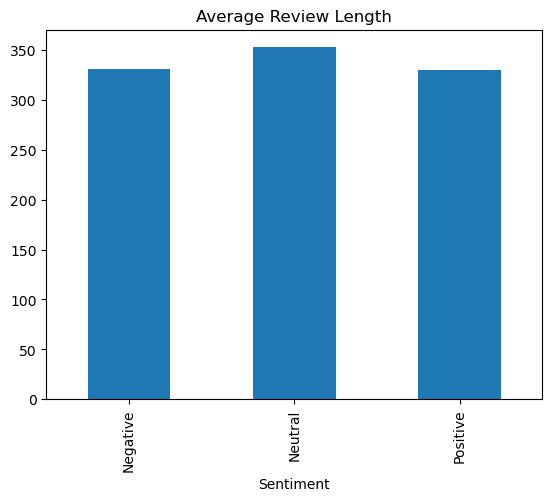

In [106]:
avg_len = df.groupby("Sentiment")["review_length"].mean()
avg_len.plot(kind='bar')
plt.title("Average Review Length")
plt.show()

# Text Preprocessing

In [107]:
# Detect Non-English Reviews
# Purpose: Identify reviews containing characters from the specified non-English script range.
df["non_english"] = df["review"].str.contains(r'[\u0900-\u0D7F]',regex=True,na=False)
df["non_english"].value_counts()

non_english
False    1427
True       13
Name: count, dtype: int64

In [108]:
df

,title,rating,body,Sentiment,review,review_length,non_english
0,Horrible product,1,Very disappointed with the overall performance...,Negative,Horrible product Very disappointed with the ov...,76,False
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,Camera quality is not like 48 megapixel Camera...,61,False
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"Overall Got the mobile on the launch date,Batt...",411,False
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,A big no from me 1. It doesn't work with 5.0GH...,394,False
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,Put your money somewhere else Not worth buying...,209,False
...,...,...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,Excellent mobile Excellent mobile,33,False
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,Never expected from samsung All over mobile pe...,216,False
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,Good value for money Battery life is good but ...,119,False
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,Unreal and whitish display It's a very bad pro...,234,False


In [109]:
#VIEW IDENTIFIED NON-ENGLISH REVIEWS
df[df["non_english"]][["title","body"]]

,title,body
7,कैसा दिखाते है उसका 10 % भी नही,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...
248,Damage product reshived,Damage product reshived hua hai or koi help na...
407,STPL SUPPLIER SEND WRONG ITEM,8 ന്റെ പണിAmazon നെ ഉം പൊക്കിപിടിച്ച് നടന്ന എന...
421,अमेज़न आपके द्वारा खरीदा samsung m12 6GB ram 12...,अमेज़न मेने आपके ऐप्प सेsamsung M126GB Ram 128 ...
460,असंतोषजनक,इस फोन में कई कमियां है जैसे इसकी नोटिफिकेशन ट...
524,पैसे की बर्बादी है ये मोबाइल,घण्टा true 48 megapixel कैमरा है !!!🔔🔔🔔🔔कैमरे ...
700,सैमसंग के मोबाइल के मेरे लिए बेस्ट रहते है।,ये सैमसंग का 5G का अच्छा मोबाइल है। मैं पहले स...
794,इस फोन में बहुत सारे प्रॉब्लम है,इस फोन में बहुत सारे प्रॉब्लम है चार्ज में लगा...
803,Samsung worst phone ever,"ना तो dual app work करता है, second whatsapp d..."
887,"बकबास फ़ोन, पैसे खड्डे में गए","Worst phone. एक दम बकबास है, स्क्रीन शॉट सिस..."


In [110]:
#Dropping non-eng rows
df = df[df["non_english"]==False].copy()

In [111]:
#Removing Temporary Language Column
df.drop("non_english", axis=1, inplace=True)

In [112]:
import sys
!{sys.executable} -m pip install emoji

# Text Cleaning 

In [113]:
# ============================================
# BASIC TEXT CLEANING
# ============================================
from bs4 import BeautifulSoup
import re
import string
import emoji

def clean_text(text):
    text = str(text)

    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep apostrophes for contractions
    text = re.sub(r"[^a-zA-Z'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text.strip()
df["clean_review"] = df["review"].apply(clean_text)

In [114]:
# ============================================
# Tokentization + STOPWORD REMOVAL + Short Word Removal (<=2)
# ============================================

#Tokenization: Splitting text into individual words/tokens — e.g., "This phone is good" → ["This", "phone", "is", "good"]
#Stopword Removal: Removing common words that usually add little meaning — [e.g., "This phone is very good" → "phone good"]
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
stop_words = stop_words - negation_words
def remove_stopwords(text):
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words and len(word) > 1 and not word.isdigit()]
    return " ".join(words)
df["clean_review"] = df["clean_review"].apply(remove_stopwords)

In [115]:
# ============================================
# LEMMATIZATION : Converting words to their base/dictionary form — [e.g., "running", "runs", "ran" → "run"]
# ============================================
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)
df["clean_review"] = df["clean_review"].apply(lemmatize_text)
df[["clean_review"]].head()

,clean_review
0,horrible product disappointed overall performa...
1,camera quality not like megapixel camera quali...
2,overall got mobile launch date battery must ap...
3,big no n't work ghz wifi frequency ghz old sch...
4,put money somewhere else not worth buying faul...


In [116]:
# ============================================
#  WORD FREQUENCY ANALYSIS
# ============================================

from collections import Counter

all_words = " ".join(df["clean_review"])
word_freq = Counter(all_words.split())
top_words = pd.DataFrame(word_freq.most_common(20),columns=["Word","Frequency"])
top_words

,Word,Frequency
0,phone,2003
1,good,1480
2,not,1427
3,camera,1110
4,battery,896
5,samsung,800
6,quality,726
7,mobile,643
8,n't,528
9,price,462


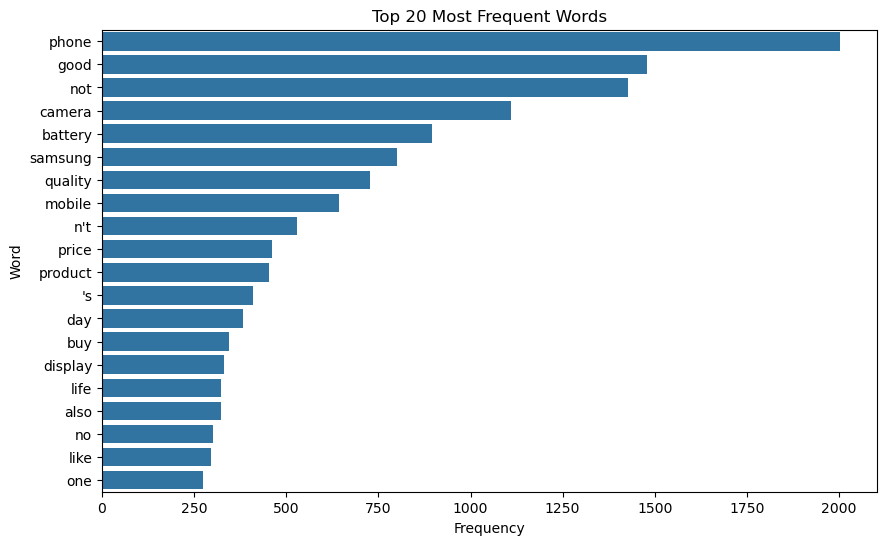

In [117]:
#Top 20 Most Frequent Words
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="Frequency",y="Word",data=top_words)
plt.title("Top 20 Most Frequent Words")
plt.show()

# Word Cloud
### Positive Reviews Word Cloud

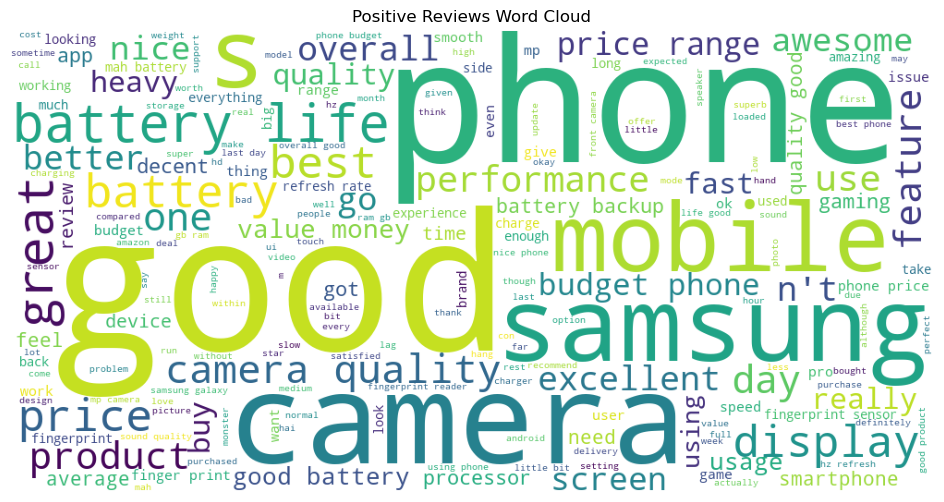

In [118]:
# Positive Reviews Word Cloud

positive_text = " ".join(df[df["Sentiment"]=="Positive"]["clean_review"])
wordcloud = WordCloud(width=1000,height=500,background_color="white").generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

### Negative Reviews Word Cloud

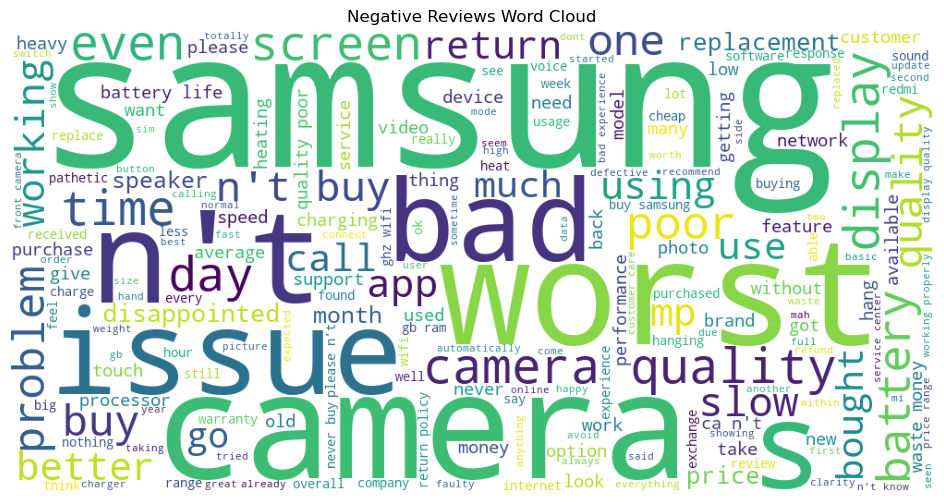

In [119]:
#Negative Reviews Word Cloud

from wordcloud import STOPWORDS

negative_text = " ".join(df[df["Sentiment"]=="Negative"]["clean_review"])
extra_words = {"phone","mobile","amazon","product","good"}
wc_stopwords = STOPWORDS.union(extra_words)
wc = WordCloud(width=1000,height=500,background_color="white",stopwords=wc_stopwords).generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [120]:
# ============================================
# BIGRAMS
# ============================================

from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2)) # Create bigrams containing exactly two words
X_bigram = bigram_vectorizer.fit_transform(df["clean_review"])
bigram_counts = pd.DataFrame({"Bigram":bigram_vectorizer.get_feature_names_out(),"Count":X_bigram.sum(axis=0).A1})
top_bigrams = bigram_counts.sort_values(by="Count",ascending=False).head(20) #The most frequently occurring two-word phrases.
top_bigrams

,Bigram,Count
4108,camera quality,307
2206,battery life,284
17136,not good,167
10579,good phone,125
20468,price range,124
3304,budget phone,107
10347,good battery,104
2108,battery backup,95
28554,value money,95
19175,phone good,81


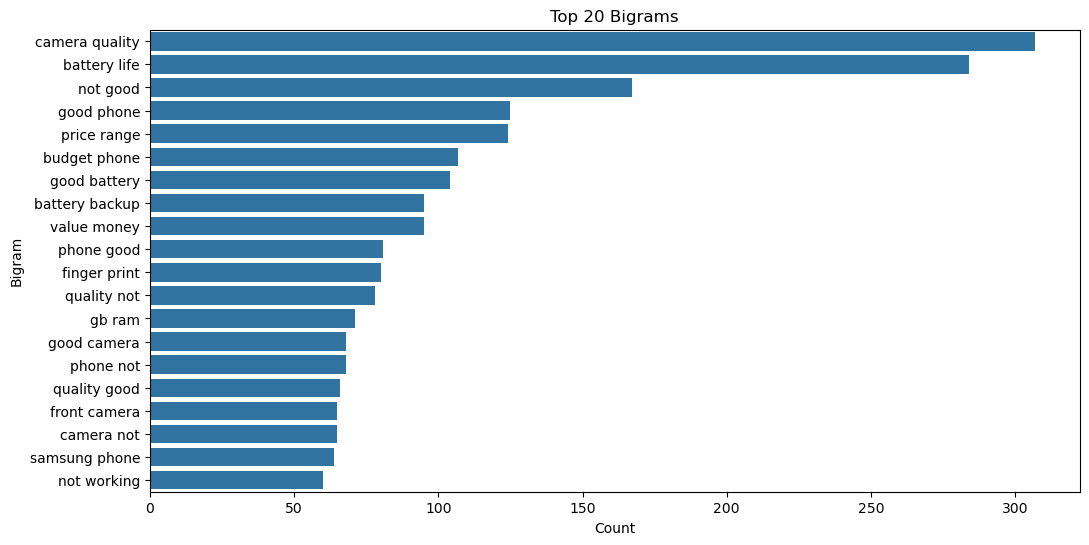

In [121]:
#Top 20 Bigrams Visualization
plt.figure(figsize=(12,6))
sns.barplot(x="Count",y="Bigram",data=top_bigrams)
plt.title("Top 20 Bigrams")
plt.show()

# VADER SENTIMENT ANALYSIS 

In [122]:
import sys
!{sys.executable} -m pip install vaderSentiment

## INITIALIZING VADER SENTIMENT ANALYZER

In [123]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [124]:
#Checking one review - TEST VADER ON A SAMPLE REVIEW
sample_review = df["clean_review"].iloc[0]
print(sample_review)
print(analyzer.polarity_scores(sample_review))

horrible product disappointed overall performance samsung
{'neg': 0.623, 'neu': 0.377, 'pos': 0.0, 'compound': -0.765}


In [125]:
# CONVERT VADER COMPOUND SCORE TO SENTIMENT
def vader_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score["compound"]
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [126]:
# APPLYING VADER TO ALL REVIEWS
df["vader_sentiment"] = df["clean_review"].apply(vader_sentiment)

In [127]:
#Compare : Vader Sentiment vs Actual Sentiment 
pd.crosstab(df["Sentiment"],df["vader_sentiment"])

vader_sentiment,Negative,Neutral,Positive
Sentiment,,,
Negative,364,17,120
Neutral,78,11,110
Positive,39,7,681


In [128]:
# CALCULATE VADER ACCURACY
from sklearn.metrics import accuracy_score
accuracy_score(df["Sentiment"],df["vader_sentiment"])

0.7400140154169587

### Heatmap

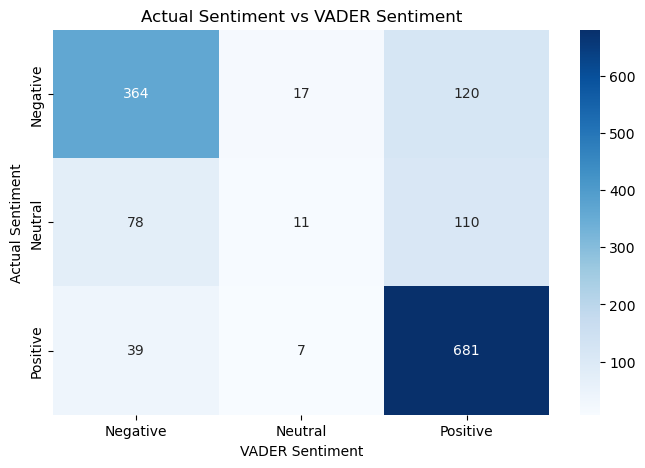

In [129]:
#  Actual Sentiment vs VADER Sentiment Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

comparison = pd.crosstab(df["Sentiment"],df["vader_sentiment"])
plt.figure(figsize=(8,5))
sns.heatmap(comparison,annot=True,fmt='d',cmap='Blues')
plt.title("Actual Sentiment vs VADER Sentiment")
plt.ylabel("Actual Sentiment")
plt.xlabel("VADER Sentiment")
plt.show()

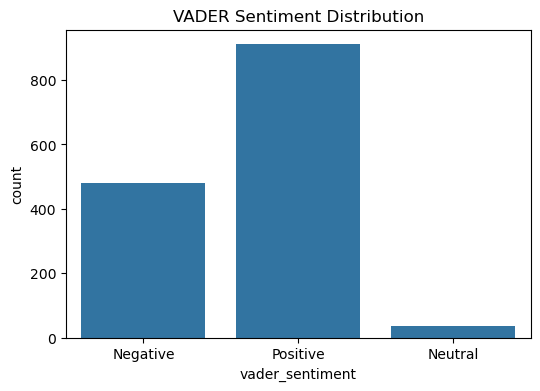

In [130]:
# VADER Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="vader_sentiment",data=df)
plt.title("VADER Sentiment Distribution")
plt.show()

In [131]:
#VADER Compound Score Distribution
df["compound_score"] = df["clean_review"].apply(lambda x:analyzer.polarity_scores(x)["compound"])

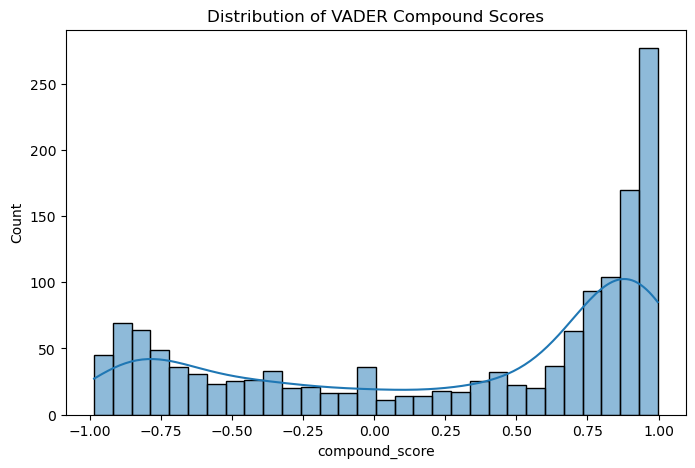

In [132]:
# DISTRIBUTION OF VADER COMPOUND SCORES
plt.figure(figsize=(8,5))
sns.histplot(df["compound_score"],bins=30,kde=True)
plt.title("Distribution of VADER Compound Scores")
plt.show()

In [133]:
print(df["Sentiment"].value_counts())
print(df["Sentiment"].value_counts(normalize=True))

Sentiment
Positive    727
Negative    501
Neutral     199
Name: count, dtype: int64
Sentiment
Positive    0.509460
Negative    0.351086
Neutral     0.139453
Name: proportion, dtype: float64


In [134]:
# ============================================================
# STEP 1: TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=df["Sentiment"]
)

print("Training data:", X_train_text.shape)
print("Testing data :", X_test_text.shape)
print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training data: (1141,)
Testing data : (286,)
Training target: (1141,)
Testing target : (286,)


# TF-IDF (Term Frequency–Inverse Document Frequency):
 - TF-IDF gives a numerical weight to a word based on how important it is in one review compared with all reviews.
 ### TF (Term Frequency):
-  Measures how often a word appears in a particular review/document.
-  TF=Total words in the review/Number of times word appears in the review​
### IDF (Inverse Document Frequency):
- Measures how rare or unique a word is across all reviews.
- IDF = log(Total number of reviews / Number of reviews containing the word)

### TF-IDF Formula:
- TF-IDF = TF × IDF

## Example:
Review 1:
"phone camera is good"   

Review 2:
"phone camera is bad"

Review 3:
"phone battery is good"

1. phone : common → lower IDF
2. battery : more distinctive → higher IDF

In [135]:
# ============================================
# TF-IDF FEATURE ENGINEERING
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=None,
    ngram_range=(1,2),
    min_df=7,
    sublinear_tf=True
)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape :", X_test.shape)

Training TF-IDF shape: (1141, 1165)
Testing TF-IDF shape : (286, 1165)


In [136]:
# ============================================
# VIEW TOP TF-IDF FEATURES
# ============================================

import numpy as np
import pandas as pd

feature_names = tfidf.get_feature_names_out()

# Total TF-IDF score for each feature
scores = np.asarray(X_train.sum(axis=0)).ravel()

# Get top 50 features
top_idx = scores.argsort()[::-1][:50]

# Create DataFrame
top_features = pd.DataFrame({
    "Feature": feature_names[top_idx],
    "Score": scores[top_idx]
})

top_features

,Feature,Score
0,phone,70.661636
1,good,63.531972
2,not,58.393617
3,camera,51.051683
4,battery,45.828484
5,samsung,44.180826
6,quality,42.911218
7,mobile,38.720702
8,product,35.411473
9,price,33.654946


In [137]:
#View Top TF-IDF Features
import numpy as np

feature_names = tfidf.get_feature_names_out()
scores = np.asarray(X.sum(axis=0)).flatten()
top_idx = scores.argsort()[::-1][:50]
top_features = pd.DataFrame({"Feature": feature_names[top_idx],"Score": scores[top_idx]})
top_features

,Feature,Score
0,able,horrible product disappointed overall performa...


In [138]:
print(df["Sentiment"].value_counts())
print(df["Sentiment"].value_counts(normalize=True))

Sentiment
Positive    727
Negative    501
Neutral     199
Name: count, dtype: int64
Sentiment
Positive    0.509460
Negative    0.351086
Neutral     0.139453
Name: proportion, dtype: float64


# Model Building and Model Evaluation

## Model Building
### STEP 1 — Import Model Building Libraries

In [139]:
# ============================================================
# MODEL BUILDING AND MODEL EVALUATION
# ============================================================

# Import function for splitting the dataset
from sklearn.model_selection import train_test_split
# Import five classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
# Import pandas for creating the model comparison table
import pandas as pd
# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

### MODEL 1 — LOGISTIC REGRESSION
### STEP 3 — Build Logistic Regression

In [140]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=0.1,
    multi_class='multinomial', 
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


### STEP 4 — Make Logistic Regression Predictions

In [141]:
# ============================================================
# LOGISTIC REGRESSION - PREDICTION
# ============================================================
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

### STEP 5 — Evaluate Logistic Regression

In [142]:
# ============================================================
# LOGISTIC REGRESSION - MODEL EVALUATION
# ============================================================
print("LOGISTIC REGRESSION")

print("Train Accuracy :", accuracy_score(y_train, y_pred_lr_train))
print("Train Precision:", precision_score(y_train, y_pred_lr_train, average="weighted"))
print("Train Recall   :", recall_score(y_train, y_pred_lr_train, average="weighted"))
print("Train F1       :", f1_score(y_train, y_pred_lr_train, average="weighted"))

print()

print("Test Accuracy  :", accuracy_score(y_test, y_pred_lr_test))
print("Test Precision :", precision_score(y_test, y_pred_lr_test, average="weighted"))
print("Test Recall    :", recall_score(y_test, y_pred_lr_test, average="weighted"))
print("Test F1        :", f1_score(y_test, y_pred_lr_test, average="weighted"))
print("Test Macro F1  :", f1_score(y_test, y_pred_lr_test, average="macro"))



C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


LOGISTIC REGRESSION
Train Accuracy : 0.7861524978089395
Train Precision: 0.6912846189989026
Train Recall   : 0.7861524978089395
Train F1       : 0.7277507660371035

Test Accuracy  : 0.7307692307692307
Test Precision : 0.6510809764398281
Test Recall    : 0.7307692307692307
Test F1        : 0.6730986527596698
Test Macro F1  : 0.5190207156308851


### STEP 6 — Classification Report

In [143]:
# ============================================================
# LOGISTIC REGRESSION - CLASSIFICATION REPORT
# ============================================================

# Display detailed performance for each sentiment class
print(classification_report(y_test, y_pred_lr_test))

              precision    recall  f1-score   support

    Negative       0.87      0.67      0.76       100
     Neutral       0.00      0.00      0.00        40
    Positive       0.68      0.97      0.80       146

    accuracy                           0.73       286
   macro avg       0.52      0.55      0.52       286
weighted avg       0.65      0.73      0.67       286



C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### STEP 7 — Confusion Matrix

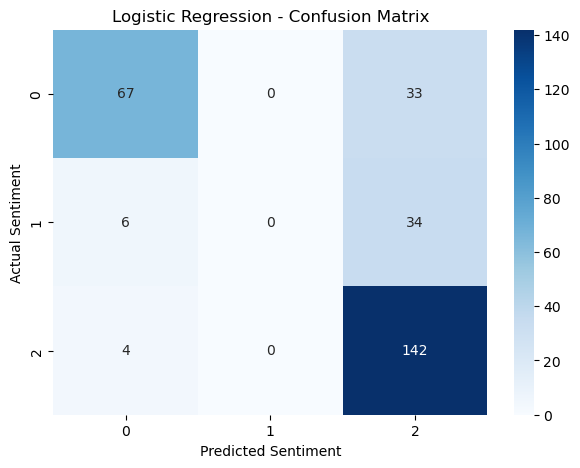

In [144]:
# ============================================================
# LOGISTIC REGRESSION - CONFUSION MATRIX
# ============================================================

# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues")
# Add labels
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
# Add title
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### MODEL 2 — MULTINOMIAL NAIVE BAYES
### STEP 8 — Build Naive Bayes

In [145]:
# ============================================================
# MODEL 2: MULTINOMIAL NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB
# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()
# Train the model using TF-IDF training features
nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


### STEP 9 — Make Predictions

In [146]:
# ============================================================
# NAIVE BAYES - PREDICTION
# ============================================================
# Predict sentiment for the test data
y_pred_nb_train = nb_model.predict(X_train)

# Predict sentiment for test data
y_pred_nb_test = nb_model.predict(X_test)
# Display first 10 predictions
print("Predicted values:")
print(y_pred_nb_test[:10])

Predicted values:
['Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Negative'
 'Negative' 'Negative' 'Negative' 'Negative']


### STEP 10 — Evaluate Naive Bayes

In [147]:
# ============================================================
# NAIVE BAYES - MODEL EVALUATION
# ============================================================
print("NAIVE BAYES")

print("Train Accuracy :", accuracy_score(y_train, y_pred_nb_train))
print("Train Precision:", precision_score(y_train, y_pred_nb_train, average="weighted"))
print("Train Recall   :", recall_score(y_train, y_pred_nb_train, average="weighted"))
print("Train F1       :", f1_score(y_train, y_pred_nb_train, average="weighted"))

print()

print("Test Accuracy  :", accuracy_score(y_test, y_pred_nb_test))
print("Test Precision :", precision_score(y_test, y_pred_nb_test, average="weighted"))
print("Test Recall    :", recall_score(y_test, y_pred_nb_test, average="weighted"))
print("Test F1        :", f1_score(y_test, y_pred_nb_test, average="weighted"))
print("Test Macro F1  :", f1_score(y_test, y_pred_nb_test, average="macro"))

NAIVE BAYES
Train Accuracy : 0.8194566170026293
Train Precision: 0.8459951133372647
Train Recall   : 0.8194566170026293
Train F1       : 0.7712069553665041

Test Accuracy  : 0.7552447552447552
Test Precision : 0.6514775547033611
Test Recall    : 0.7552447552447552
Test F1        : 0.6971101187968658
Test Macro F1  : 0.5371084337349398


C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### STEP 11 — Classification Report

In [148]:
# ============================================================
# NAIVE BAYES - CLASSIFICATION REPORT
# ============================================================
print(classification_report(y_test, y_pred_nb_test))

              precision    recall  f1-score   support

    Negative       0.78      0.78      0.78       100
     Neutral       0.00      0.00      0.00        40
    Positive       0.74      0.95      0.83       146

    accuracy                           0.76       286
   macro avg       0.51      0.58      0.54       286
weighted avg       0.65      0.76      0.70       286



C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### STEP 12 — Confusion Matrix

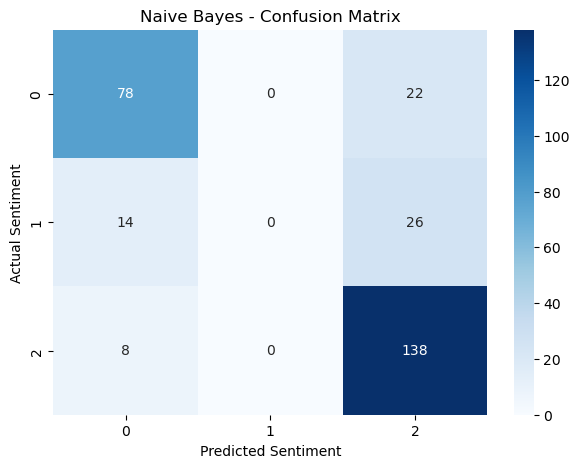

In [149]:
# ============================================================
# NAIVE BAYES - CONFUSION MATRIX
# ============================================================

# Generate confusion matrix

cm_nb = confusion_matrix(y_test, y_pred_nb_test)
# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

### MODEL 3 — LINEAR SVM
### STEP 13 — Build Linear SVM

In [150]:
# ============================================================
# MODEL 3: LINEAR SUPPORT VECTOR MACHINE
# ============================================================

# Create the Linear SVM model
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=0.12,
    max_iter=1000,
    random_state=42
)
# Train the SVM model
svm_model.fit(X_train, y_train)
print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


### STEP 14 — Make Predictions

In [151]:
# ============================================================
# LINEAR SVM - PREDICTION
# ============================================================
# Predict sentiment for train data
y_pred_svm_train = svm_model.predict(X_train)

# Predict sentiment for test data
y_pred_svm_test = svm_model.predict(X_test)
# Display first 10 predictions
print("Predicted values:")
print(y_pred_svm_test[:10])

Predicted values:
['Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Negative'
 'Negative' 'Negative' 'Negative' 'Negative']


### STEP 15 — Evaluate SVM

In [152]:
# ============================================================
# LINEAR SVM - MODEL EVALUATION
# ============================================================
print("LINEAR SVM")

print("Train Accuracy :", accuracy_score(y_train, y_pred_svm_train))
print("Train Precision:", precision_score(y_train, y_pred_svm_train, average="weighted"))
print("Train Recall   :", recall_score(y_train, y_pred_svm_train, average="weighted"))
print("Train F1       :", f1_score(y_train, y_pred_svm_train, average="weighted"))
print()

print("Test Accuracy  :", accuracy_score(y_test, y_pred_svm_test))
print("Test Precision :", precision_score(y_test, y_pred_svm_test, average="weighted"))
print("Test Recall    :", recall_score(y_test, y_pred_svm_test, average="weighted"))
print("Test F1        :", f1_score(y_test, y_pred_svm_test, average="weighted"))
print("Test Macro F1  :", f1_score(y_test, y_pred_svm_test, average="macro"))

LINEAR SVM
Train Accuracy : 0.8694127957931639
Train Precision: 0.8842497987688072
Train Recall   : 0.8694127957931639
Train F1       : 0.8414026944116741

Test Accuracy  : 0.7937062937062938
Test Precision : 0.7951909021009412
Test Recall    : 0.7937062937062938
Test F1        : 0.7521800524896499
Test Macro F1  : 0.620662768031189


### STEP 16 — Classification Report

In [153]:
# ============================================================
# LINEAR SVM - CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test, y_pred_svm_test))

              precision    recall  f1-score   support

    Negative       0.81      0.84      0.82       100
     Neutral       0.80      0.10      0.18        40
    Positive       0.79      0.95      0.86       146

    accuracy                           0.79       286
   macro avg       0.80      0.63      0.62       286
weighted avg       0.80      0.79      0.75       286



### STEP 17 — Confusion Matrix

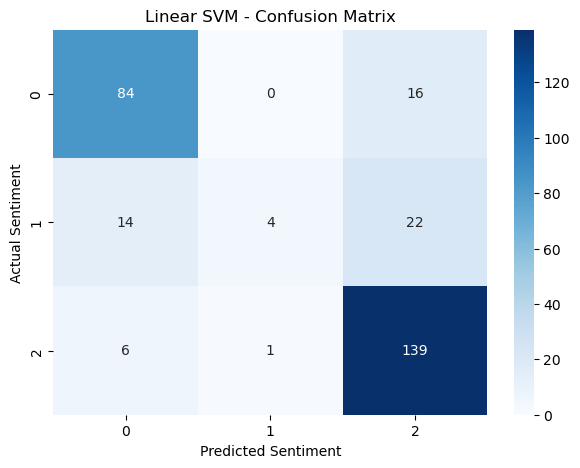

In [154]:
# ============================================================
# LINEAR SVM - CONFUSION MATRIX
# ============================================================

cm_svm = confusion_matrix(y_test, y_pred_svm_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Linear SVM - Confusion Matrix")
plt.show()

### MODEL 4 — DECISION TREE
### STEP 18 — Build Decision Tree

In [155]:
# ============================================================
# MODEL 4: DECISION TREE CLASSIFIER
# ============================================================

# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Create the Decision Tree model
# max_depth=20 limits the depth of the tree
# and helps reduce overfitting
# random_state=42 makes results reproducible
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the Decision Tree
dt_model.fit(X_train,y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### STEP 19 — Make Predictions

In [156]:
# ============================================================
# DECISION TREE - PREDICTION
# ============================================================

# Predict sentiment for train data
y_pred_dt_train = dt_model.predict(X_train)

# Predict sentiment for test data
y_pred_dt_test = dt_model.predict(X_test)
# Display first 10 predictions
print("Predicted values:")
print(y_pred_dt_test[:10])

Predicted values:
['Positive' 'Negative' 'Neutral' 'Negative' 'Negative' 'Neutral'
 'Negative' 'Negative' 'Positive' 'Negative']


### STEP 20 — Evaluate Decision Tree

In [157]:
# ============================================================
# DECISION TREE - MODEL EVALUATION
# ============================================================
print("DECISION TREE")

print("Train Accuracy :", accuracy_score(y_train, y_pred_dt_train))
print("Train Precision:", precision_score(y_train, y_pred_dt_train, average="weighted"))
print("Train Recall   :", recall_score(y_train, y_pred_dt_train, average="weighted"))
print("Train F1       :", f1_score(y_train, y_pred_dt_train, average="weighted"))
print()

print("Test Accuracy  :", accuracy_score(y_test, y_pred_dt_test))
print("Test Precision :", precision_score(y_test, y_pred_dt_test, average="weighted"))
print("Test Recall    :", recall_score(y_test, y_pred_dt_test, average="weighted"))
print("Test F1        :", f1_score(y_test, y_pred_dt_test, average="weighted"))
print("Test Macro F1  :", f1_score(y_test, y_pred_dt_test, average="macro"))

DECISION TREE
Train Accuracy : 0.8536371603856266
Train Precision: 0.8474928148782027
Train Recall   : 0.8536371603856266
Train F1       : 0.8489306420332019

Test Accuracy  : 0.6678321678321678
Test Precision : 0.6452441492893288
Test Recall    : 0.6678321678321678
Test F1        : 0.6544217828867606
Test Macro F1  : 0.5486669978473256


### STEP 21 — Classification Report

In [158]:
# ============================================================
# DECISION TREE - CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test, y_pred_dt_test))

              precision    recall  f1-score   support

    Negative       0.66      0.67      0.67       100
     Neutral       0.27      0.17      0.21        40
    Positive       0.74      0.80      0.77       146

    accuracy                           0.67       286
   macro avg       0.56      0.55      0.55       286
weighted avg       0.65      0.67      0.65       286



### STEP 22 — Confusion Matrix

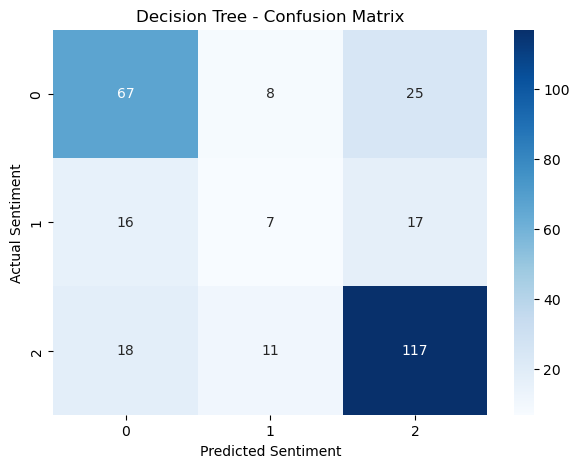

In [159]:
# ============================================================
# DECISION TREE - CONFUSION MATRIX
# ============================================================

cm_dt = confusion_matrix(y_test, y_pred_dt_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_dt,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### MODEL 5 — RANDOM FOREST
### STEP 23 — Build Random Forest

In [160]:
# ============================================================
# MODEL 5: RANDOM FOREST CLASSIFIER
# ============================================================

# Create the Random Forest model
# n_estimators=100 means the model creates 100 trees
# n_jobs=-1 allows the model to use all available CPU cores
# random_state=42 ensures reproducible results
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model
rf_model.fit(X_train,y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### STEP 24 — Make Predictions

In [161]:
# ============================================================
# RANDOM FOREST - PREDICTION
# ============================================================
# Predict sentiment for train data
y_pred_rf_train = rf_model.predict(X_train)

# Predict sentiment for test data
y_pred_rf_test = rf_model.predict(X_test)

# Display first 10 predictions
print("Predicted values:")
print(y_pred_rf_test[:10])

Predicted values:
['Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Negative'
 'Negative' 'Negative' 'Negative' 'Negative']


### STEP 25 — Evaluate Random Forest

In [162]:
# ============================================================
# RANDOM FOREST - MODEL EVALUATION
# ============================================================
print("RANDOM FOREST")

print("Train Accuracy :", accuracy_score(y_train, y_pred_rf_train))
print("Train Precision:", precision_score(y_train, y_pred_rf_train, average="weighted"))
print("Train Recall   :", recall_score(y_train, y_pred_rf_train, average="weighted"))
print("Train F1       :", f1_score(y_train, y_pred_rf_train, average="weighted"))
print()

print("Test Accuracy  :", accuracy_score(y_test, y_pred_rf_test))
print("Test Precision :", precision_score(y_test, y_pred_rf_test, average="weighted"))
print("Test Recall    :", recall_score(y_test, y_pred_rf_test, average="weighted"))
print("Test F1        :", f1_score(y_test, y_pred_rf_test, average="weighted"))
print("Test Macro F1  :", f1_score(y_test, y_pred_rf_test, average="macro"))

RANDOM FOREST
Train Accuracy : 0.8177037686240141
Train Precision: 0.8438739842331635
Train Recall   : 0.8177037686240141
Train F1       : 0.7600627518723325

Test Accuracy  : 0.7447552447552448
Test Precision : 0.6448297934335169
Test Recall    : 0.7447552447552448
Test F1        : 0.6866136364702826
Test Macro F1  : 0.5284572683462453


C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### STEP 26 — Classification Report

In [163]:
# ============================================================
# RANDOM FOREST - CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test, y_pred_rf_test))

              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76       100
     Neutral       0.00      0.00      0.00        40
    Positive       0.72      0.95      0.82       146

    accuracy                           0.74       286
   macro avg       0.50      0.56      0.53       286
weighted avg       0.64      0.74      0.69       286



C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### STEP 27 — Confusion Matrix

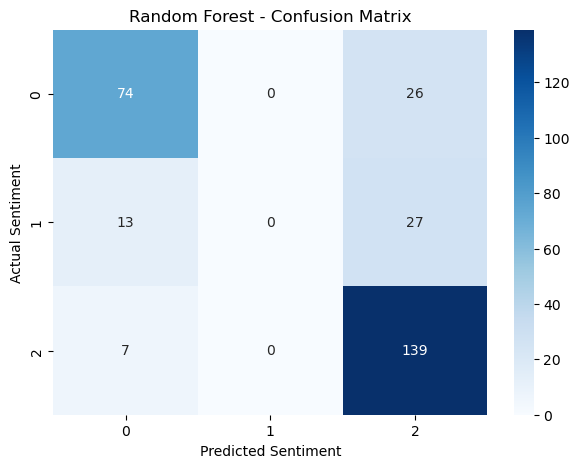

In [164]:
# ============================================================
# RANDOM FOREST - CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Random Forest - Confusion Matrix")
plt.show()

### MODEL COMPARISON

Now you have evaluated all **five models.**

### STEP 28 — Create Model Comparison Table

In [165]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import LinearSVC



# ============================================================
# STEP 28.2: MODEL PERFORMANCE COMPARISON
# ============================================================
results_dict = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Decision Tree",
        "Random Forest",
    ],
    "Train Accuracy": [
        accuracy_score(y_train, y_pred_lr_train),
        accuracy_score(y_train, y_pred_nb_train),
        accuracy_score(y_train, y_pred_svm_train),
        accuracy_score(y_train, y_pred_dt_train),
        accuracy_score(y_train, y_pred_rf_train),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr_test),
        accuracy_score(y_test, y_pred_nb_test),
        accuracy_score(y_test, y_pred_svm_test),
        accuracy_score(y_test, y_pred_dt_test),
        accuracy_score(y_test, y_pred_rf_test),
    ],
    "Test F1": [
        f1_score(y_test, y_pred_lr_test, average="weighted"),
        f1_score(y_test, y_pred_nb_test, average="weighted"),
        f1_score(y_test, y_pred_svm_test, average="weighted"),
        f1_score(y_test, y_pred_dt_test, average="weighted"),
        f1_score(y_test, y_pred_rf_test, average="weighted"),
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_lr_test, average="macro"),
        f1_score(y_test, y_pred_nb_test, average="macro"),
        f1_score(y_test, y_pred_svm_test, average="macro"),
        f1_score(y_test, y_pred_dt_test, average="macro"),
        f1_score(y_test, y_pred_rf_test, average="macro"),
    ],
}

# Convert final comparison dictionary to a DataFrame
results= pd.DataFrame(results_dict)
results


,Model,Train Accuracy,Test Accuracy,Test F1,Macro F1
0,Logistic Regression,0.786152,0.730769,0.673099,0.519021
1,Naive Bayes,0.819457,0.755245,0.697110,0.537108
2,Linear SVM,0.869413,0.793706,0.752180,0.620663
3,Decision Tree,0.853637,0.667832,0.654422,0.548667
4,Random Forest,0.817704,0.744755,0.686614,0.528457


In [166]:

from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

bagging = BaggingClassifier(
    estimator=LogisticRegression(max_iter=2000),
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

train_pred = bagging.predict(X_train)
test_pred = bagging.predict(X_test)

print("Bagging")
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))
print("Test Macro F1  :", f1_score(y_test, test_pred, average="macro"))

Bagging
Train Accuracy: 0.8816827344434707
Test Accuracy : 0.7797202797202797
Test Macro F1  : 0.6194328602087601


In [167]:
C_values = [0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.35, 0.40]
for C in C_values:

    svm = LinearSVC(
        C=C,
        penalty="l2",
        random_state=42
    )

    svm.fit(X_train, y_train)

    pred = svm.predict(X_test)

    print(
        f"C={C:.2f} | "
        f"Accuracy={accuracy_score(y_test, pred):.4f} | "
        f"Macro F1={f1_score(y_test, pred, average='macro'):.4f}"
    )

C=0.10 | Accuracy=0.7867 | Macro F1=0.6036
C=0.12 | Accuracy=0.7937 | Macro F1=0.6207
C=0.15 | Accuracy=0.7902 | Macro F1=0.6276
C=0.18 | Accuracy=0.7902 | Macro F1=0.6272
C=0.20 | Accuracy=0.7867 | Macro F1=0.6247
C=0.25 | Accuracy=0.7867 | Macro F1=0.6237
C=0.30 | Accuracy=0.7832 | Macro F1=0.6208
C=0.35 | Accuracy=0.7797 | Macro F1=0.6177
C=0.40 | Accuracy=0.7622 | Macro F1=0.6040


In [168]:
# ============================================================
# COMPLETE MODEL PERFORMANCE COMPARISON
# Accuracy, Precision, Recall and F1 Score
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Store model names and their TEST predictions
# ------------------------------------------------------------

model_predictions = {
    "Logistic Regression": y_pred_lr_test,
    "Naive Bayes": y_pred_nb_test,
    "Linear SVM": y_pred_svm_test,
    "Decision Tree": y_pred_dt_test,
    "Random Forest": y_pred_rf_test,
    "Bagging": test_pred
}

# ------------------------------------------------------------
# Calculate metrics automatically
# ------------------------------------------------------------

results = []

for model_name, predictions in model_predictions.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

# Convert scores to percentage
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]] *= 100

# Round to 2 decimal places
results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(2)

# Display table
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,73.08,65.11,73.08,67.31
1,Naive Bayes,75.52,65.15,75.52,69.71
2,Linear SVM,79.37,79.52,79.37,75.22
3,Decision Tree,66.78,64.52,66.78,65.44
4,Random Forest,74.48,64.48,74.48,68.66
5,Bagging,77.97,74.59,77.97,74.63


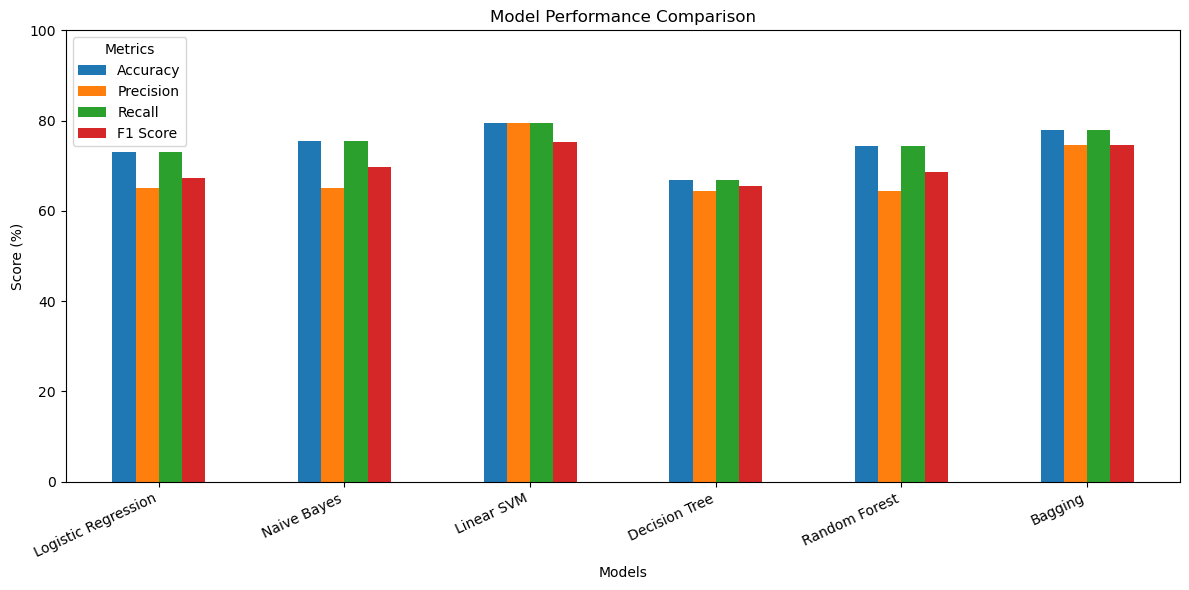

In [169]:
# ============================================================
# MODEL PERFORMANCE VISUALIZATION
# ============================================================

plot_df = results_df.set_index("Model")

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

In [170]:
# ============================================================
# SVM - PREDICT SENTIMENT FOR NEW REVIEW
# ============================================================

# Enter a new review
new_review = input("Enter your review: ")

# Apply the same preprocessing used during training
cleaned_review = clean_text(new_review)

# Convert text into TF-IDF features
review_tfidf = tfidf.transform([cleaned_review])

# Predict sentiment
prediction = svm_model.predict(review_tfidf)[0]

# Display result
print("\nReview:", new_review)
print("Predicted Sentiment:", prediction)

Enter your review:  It is good



Review: It is good
Predicted Sentiment: Positive


# Save The Model

In [171]:
import joblib

joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']